<a href="https://colab.research.google.com/github/kmk0909/2026-BDA/blob/main/code/09w_data_vis_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##9.1 산점도와 막대 그래프  

In [1]:
!pip install koreanize-matplotlib
%config InlineBackend.figure_format = 'retina'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 42.2 MB/s eta 0:00:00


In [2]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (5, 3)

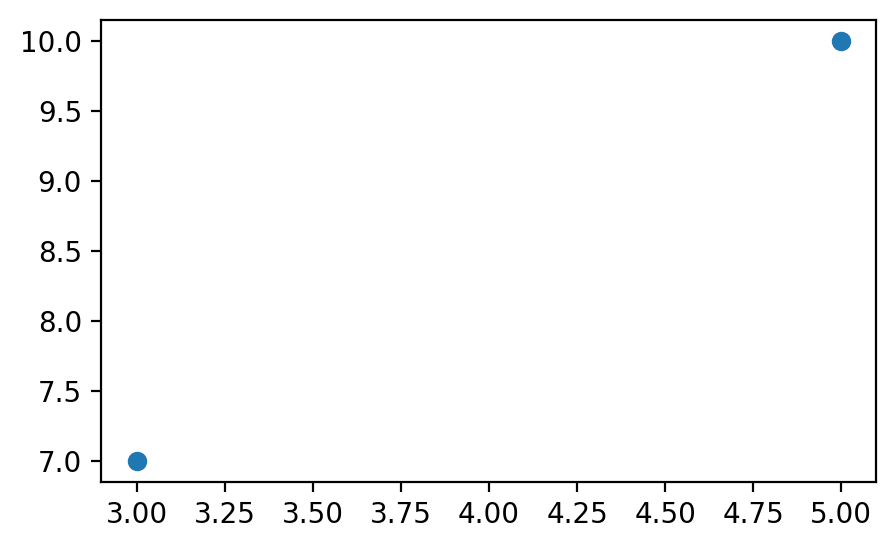

In [ ]:
plt.scatter([3, 5], [7, 10])
plt.show()

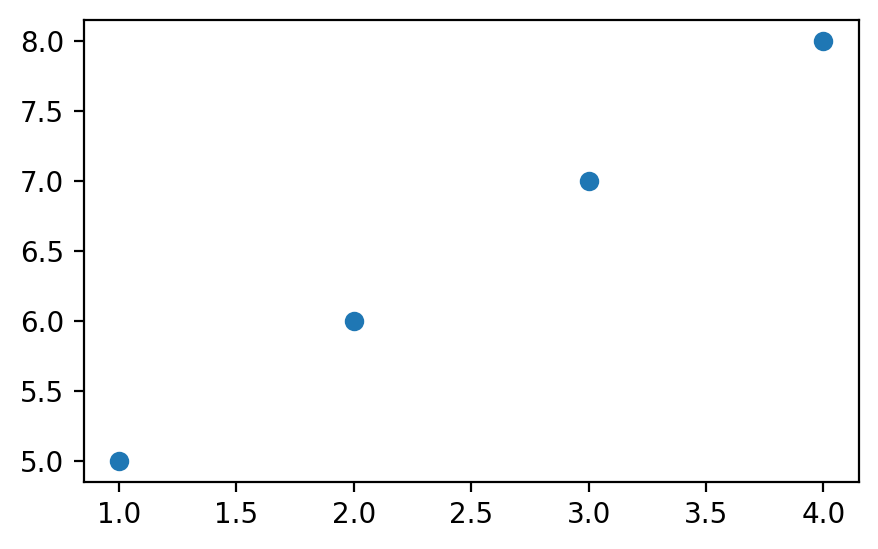

In [ ]:
plt.scatter(range(1, 5), range(5, 9))
plt.show()

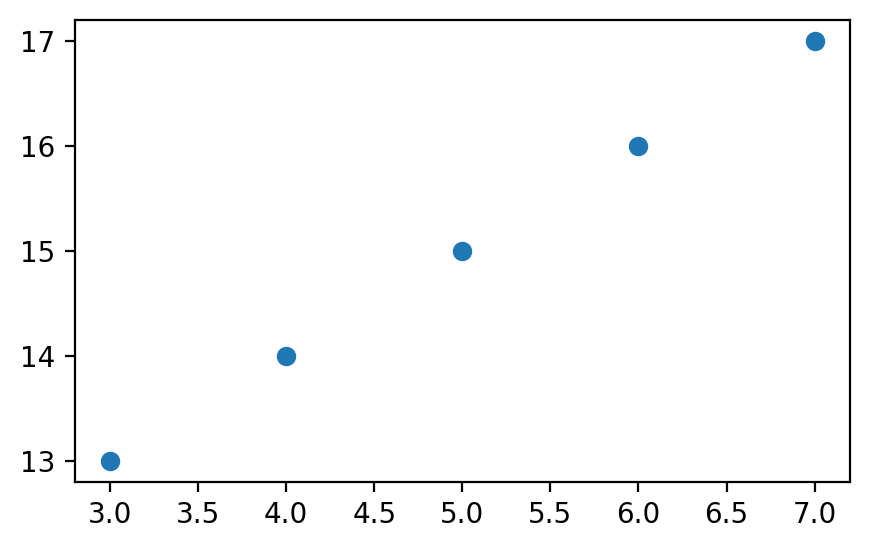

In [ ]:
plt.scatter(range(3, 8), range(13, 18))
plt.show()

In [3]:

import pandas as pd
!pip install pydataset


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 53.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939415 sha256=460f92b8fda934e84a6201a2c12abdb6c5fab169f525992e938015b6c271a767
  Stored in directory: /root/.cache/pip/wheels/4c/82/ad/f04abc617222b10438b1285ab9b5cfaecd180c10a7c81cff54
Successfully built pydataset


In [ ]:
from pydataset import data

tg = data('ToothGrowth')
tg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60 entries, 1 to 60
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   len     60 non-null     float64
 1   supp    60 non-null     object 
 2   dose    60 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.9+ KB


In [ ]:
tg.tail()

,len,supp,dose
56,30.9,OJ,2.0
57,26.4,OJ,2.0
58,27.3,OJ,2.0
59,29.4,OJ,2.0
60,23.0,OJ,2.0


In [ ]:
tg.supp.value_counts()

,count
supp,
VC,30
OJ,30


In [ ]:
tg.dose.value_counts()

,count
dose,
0.5,20
1.0,20
2.0,20


In [ ]:
tg.describe()

,len,dose
count,60.000000,60.000000
mean,18.813333,1.166667
std,7.649315,0.628872
min,4.200000,0.500000
25%,13.075000,0.500000
50%,19.250000,1.000000
75%,25.275000,2.000000
max,33.900000,2.000000


In [ ]:
!apt-get update -qq
!apt-get install -y fonts-nanum

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 75 not upgraded.


In [ ]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 75 not upgraded.


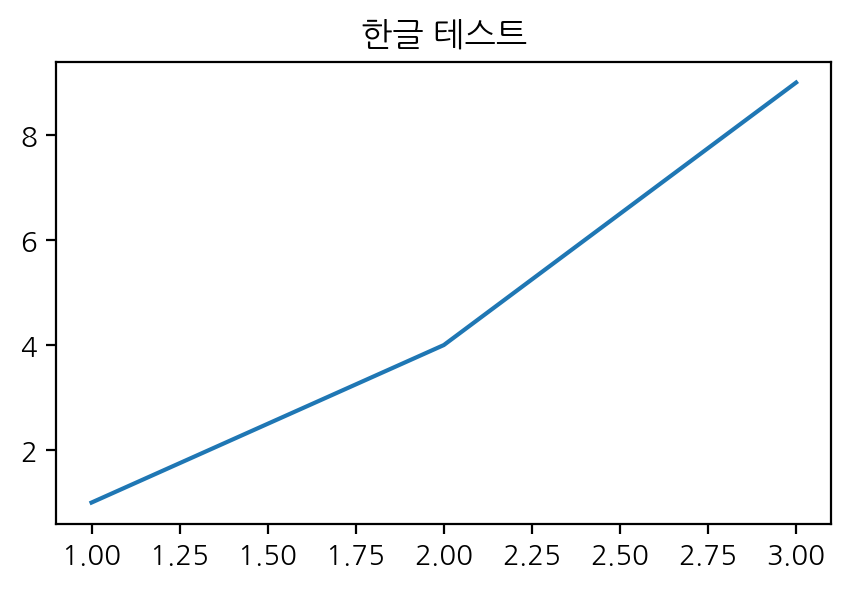

In [ ]:
# 1. 나눔폰트 설치
!apt-get update -qq
!apt-get install -y fonts-nanum

# 2. matplotlib 캐시 완전 삭제
import matplotlib.font_manager as fm
import shutil

shutil.rmtree('/root/.cache/matplotlib', ignore_errors=True)

# 3. 폰트 직접 추가 (핵심)
import matplotlib.pyplot as plt

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

# 폰트 이름 가져오기
font_name = fm.FontProperties(fname=font_path).get_name()

# 4. 적용
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# 5. 테스트
plt.figure()
plt.title("한글 테스트")
plt.plot([1,2,3],[1,4,9])
plt.show()

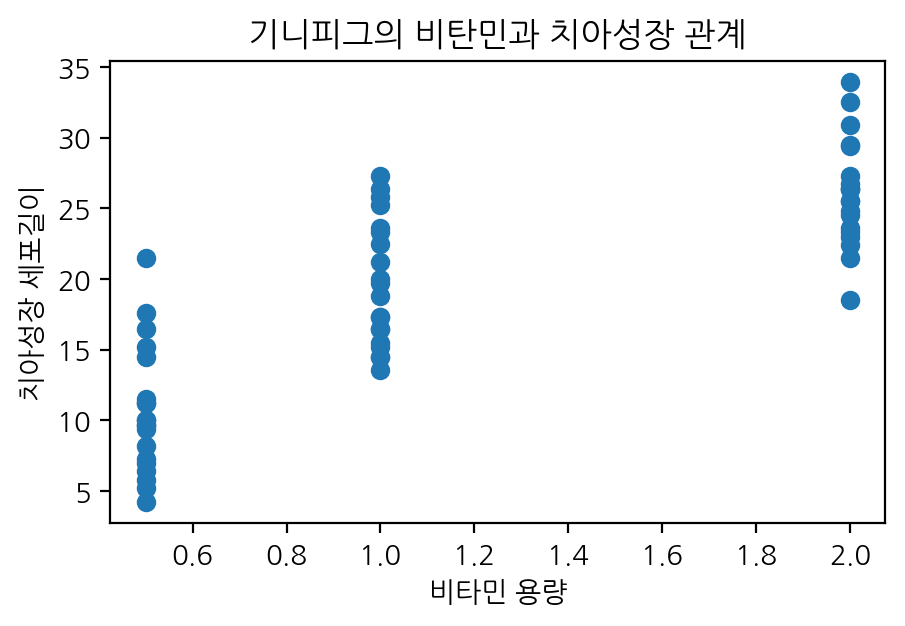

In [ ]:
plt.scatter(tg.dose, tg.len)
plt.title("기니피그의 비탄민과 치아성장 관계")
plt.xlabel("비타민 용량")
plt.ylabel("치아성장 세포길이")
plt.show()

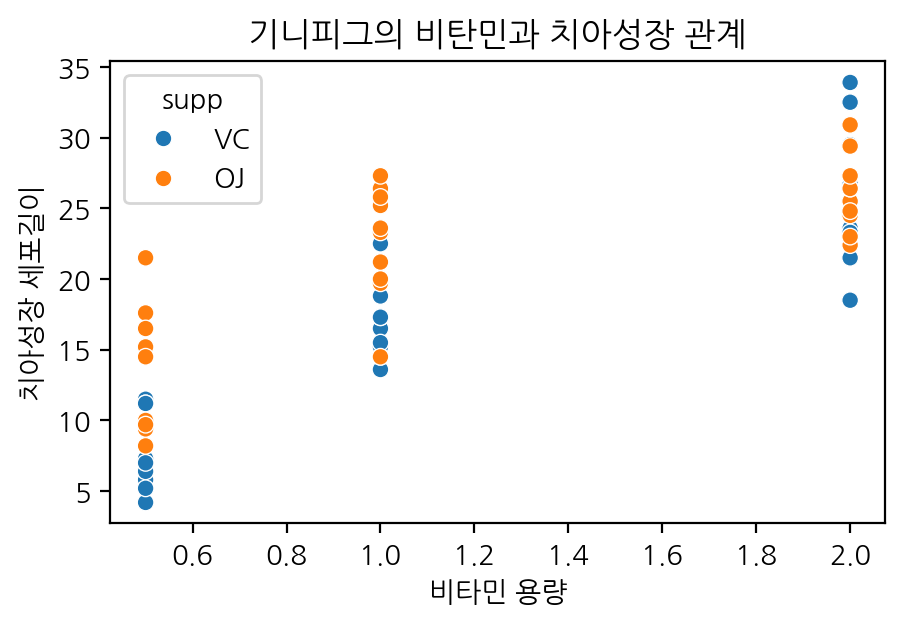

In [ ]:
import seaborn as sns
sns.scatterplot(data=tg, x='dose', y='len', hue='supp')
plt.title("기니피그의 비탄민과 치아성장 관계")
plt.xlabel("비타민 용량")
plt.ylabel("치아성장 세포길이")
plt.show()


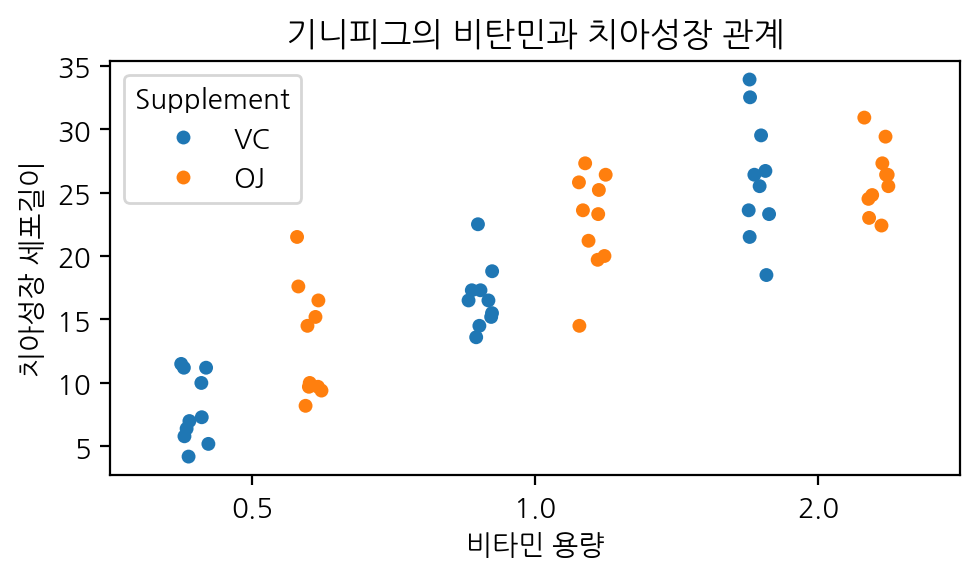

In [ ]:
import seaborn as sns
sns.stripplot(data=tg, x='dose', y='len', hue='supp', dodge='True')
plt.title("기니피그의 비탄민과 치아성장 관계")
plt.xlabel("비타민 용량")
plt.ylabel("치아성장 세포길이")
plt.legend(title='Supplement')
plt.tight_layout()
plt.show()

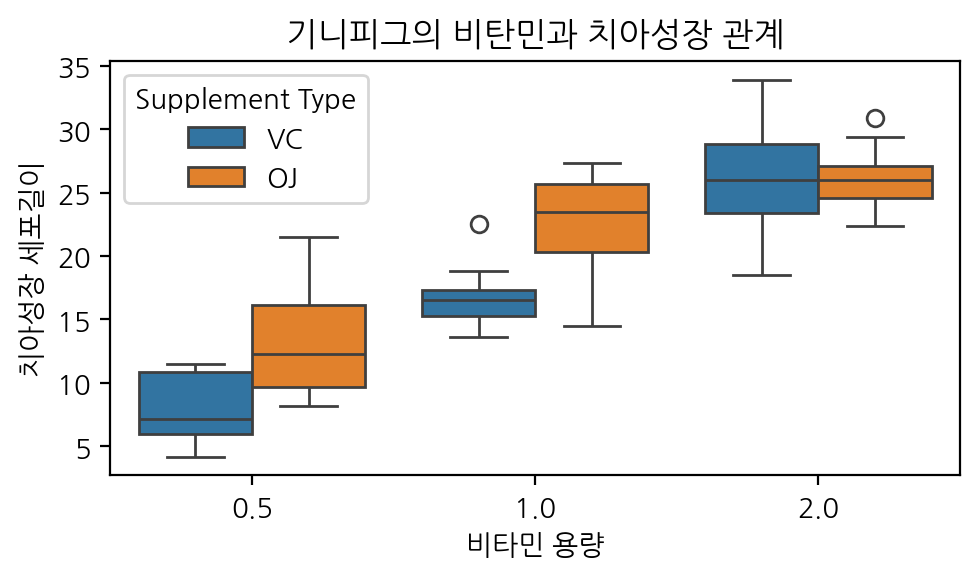

In [ ]:
import seaborn as sns
sns.boxplot(data=tg, x='dose', y='len', hue='supp')

plt.title("기니피그의 비탄민과 치아성장 관계")
plt.xlabel("비타민 용량")
plt.ylabel("치아성장 세포길이")
plt.legend(title='Supplement Type')
plt.tight_layout()
plt.show()

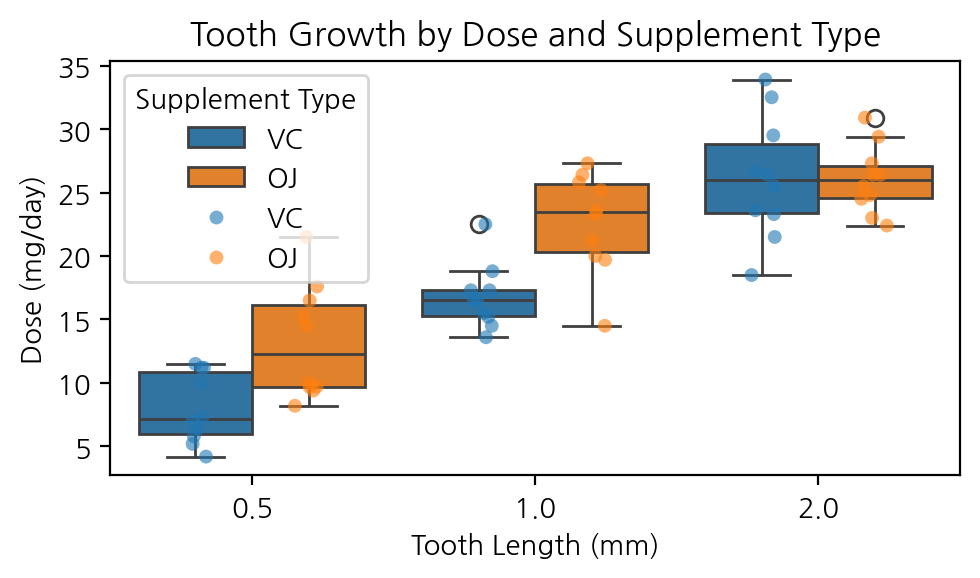

In [ ]:
sns.boxplot(data=tg, x='dose', y='len', hue='supp')
sns.stripplot(data=tg, x='dose', y='len', hue='supp',
dodge=True, alpha=0.6)
plt.title('Tooth Growth by Dose and Supplement Type')
plt.ylabel('Dose (mg/day)')
plt.xlabel('Tooth Length (mm)')
plt.legend(title='Supplement Type')
plt.tight_layout()
plt.show()

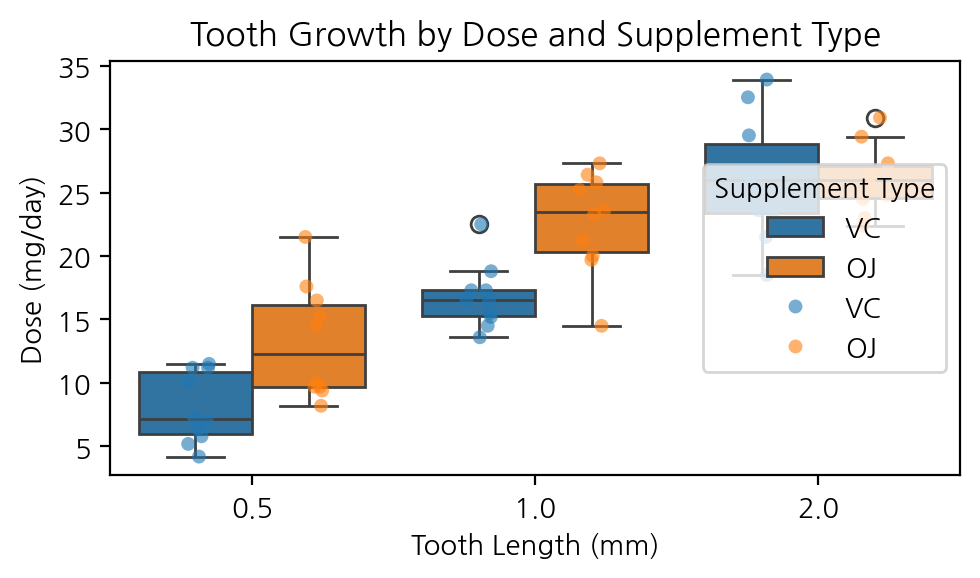

In [ ]:
sns.boxplot(data=tg, x='dose', y='len', hue='supp')
sns.stripplot(data=tg, x='dose', y='len', hue='supp',
dodge=True, alpha=0.6)
plt.title('Tooth Growth by Dose and Supplement Type')
plt.ylabel('Dose (mg/day)')
plt.xlabel('Tooth Length (mm)')
plt.legend(title='Supplement Type', loc='right')
plt.tight_layout()
plt.show()

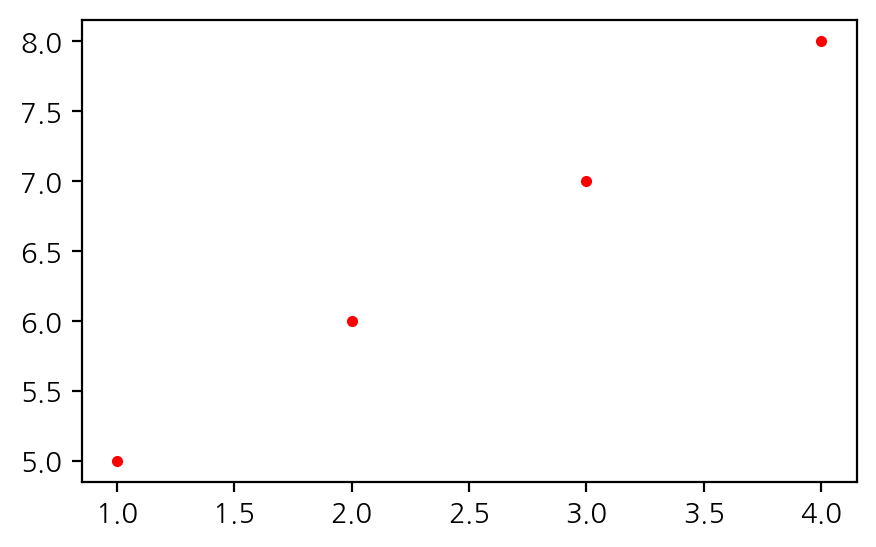

In [ ]:
plt.plot([1,2,3,4,], [5,6,7,8], ls='', marker='.', color='red')

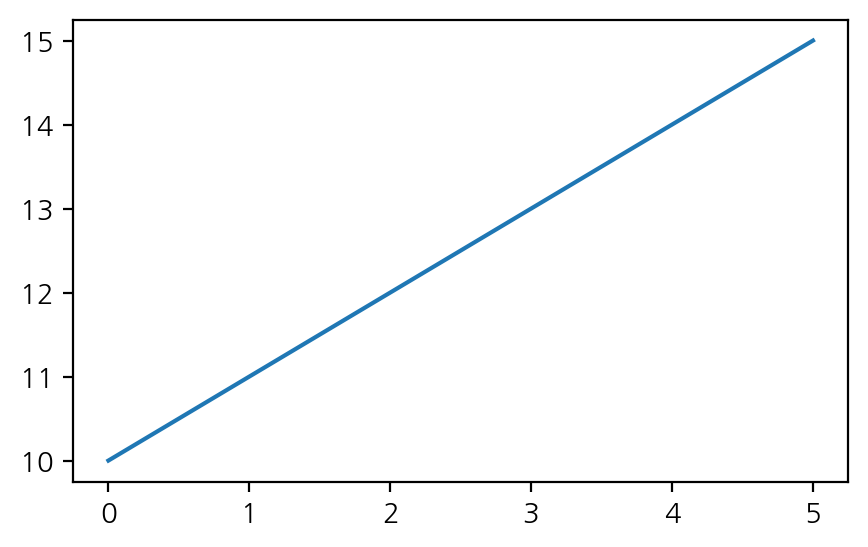

In [ ]:
import matplotlib.pyplot as plt
plt.plot(range(10, 16))

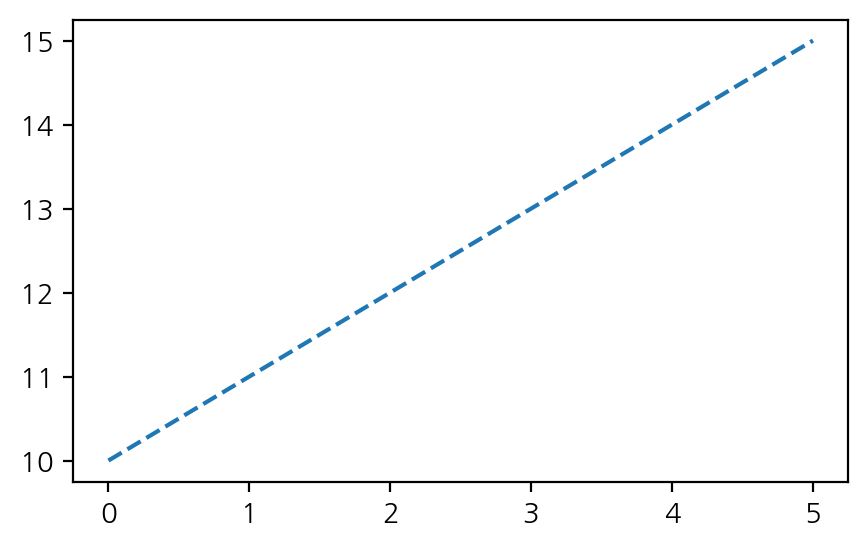

In [ ]:
plt.plot(range(10, 16), linestyle='--')

Text(0, 0.5, '$y = x^2$')

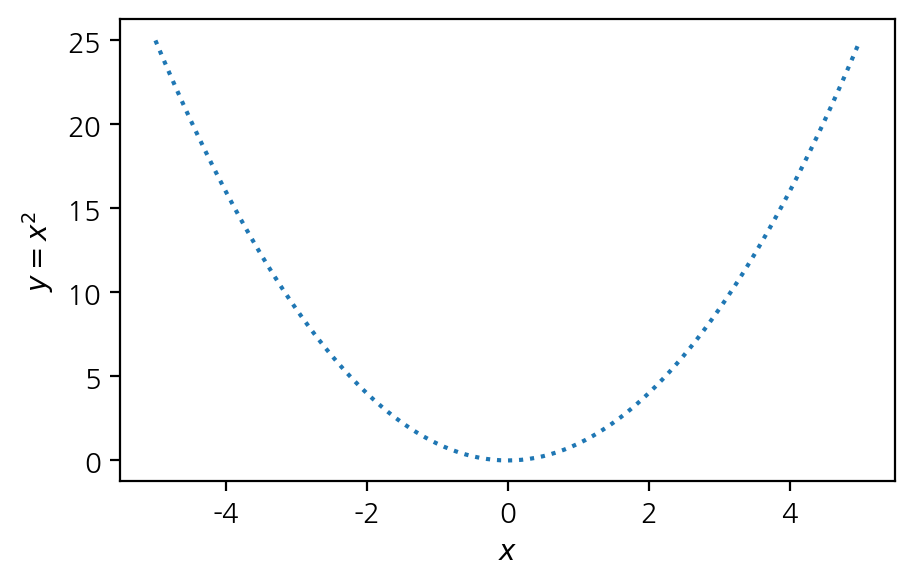

In [ ]:
import numpy as np
x = np.arange(-5, 5.1, 0.1)
plt.plot(x, x**2, ls=":")
plt.xlabel('$x$')
plt.ylabel('$y = x^2$')

In [ ]:
airpsngr = data('AirPassengers')
airpsngr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 1 to 144
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   time           144 non-null    float64
 1   AirPassengers  144 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 3.4 KB


Text(0, 0.5, '승객수')

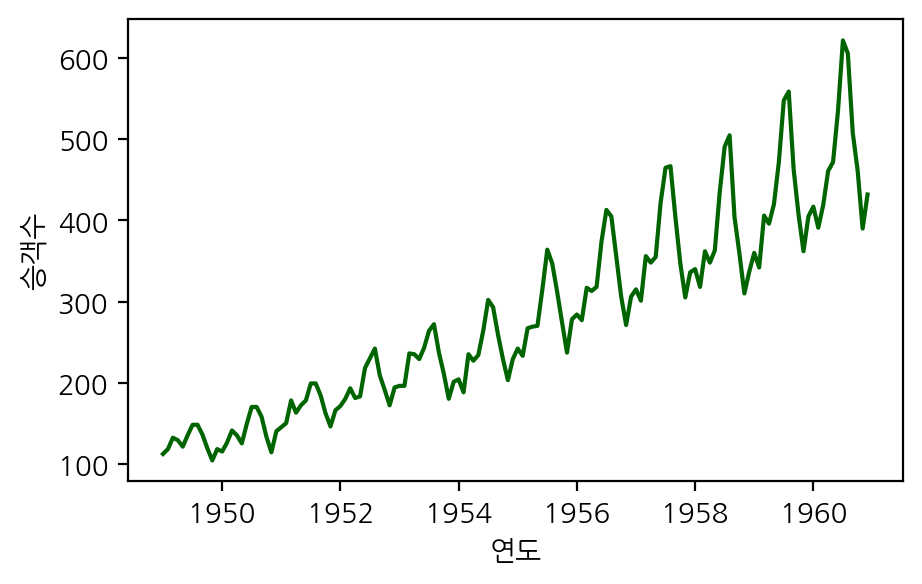

In [ ]:
plt.plot(airpsngr.time, airpsngr.AirPassengers, color = 'darkgreen')
plt.xlabel('연도')
plt.ylabel('승객수')

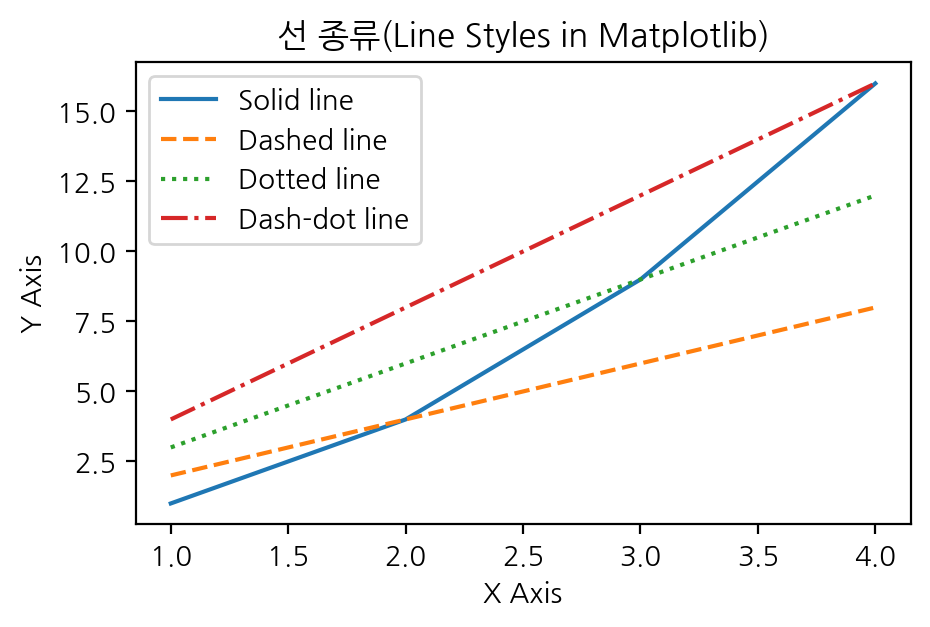

In [ ]:
import matplotlib.pyplot as plt

# 데이터 준비
x = [1, 2, 3, 4]
y1 = [1, 4, 9, 16]
y2 = [2, 4, 6, 8]
y3 = [3, 6, 9, 12]
y4 = [4, 8, 12, 16]

# 선 스타일별로 그래프 그리기
plt.plot(x, y1, linestyle='-', label='Solid line')        # 실선
plt.plot(x, y2, linestyle='--', label='Dashed line')       # 점선
plt.plot(x, y3, linestyle=':', label='Dotted line')       # 도트 선
plt.plot(x, y4, linestyle='-.', label='Dash-dot line')    # 대시 도트 선

# 그래프 제목과 축 레이블
plt.title("선 종류(Line Styles in Matplotlib)")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")

# 범례 추가
plt.legend()

# 그래프 보여주기
plt.show()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

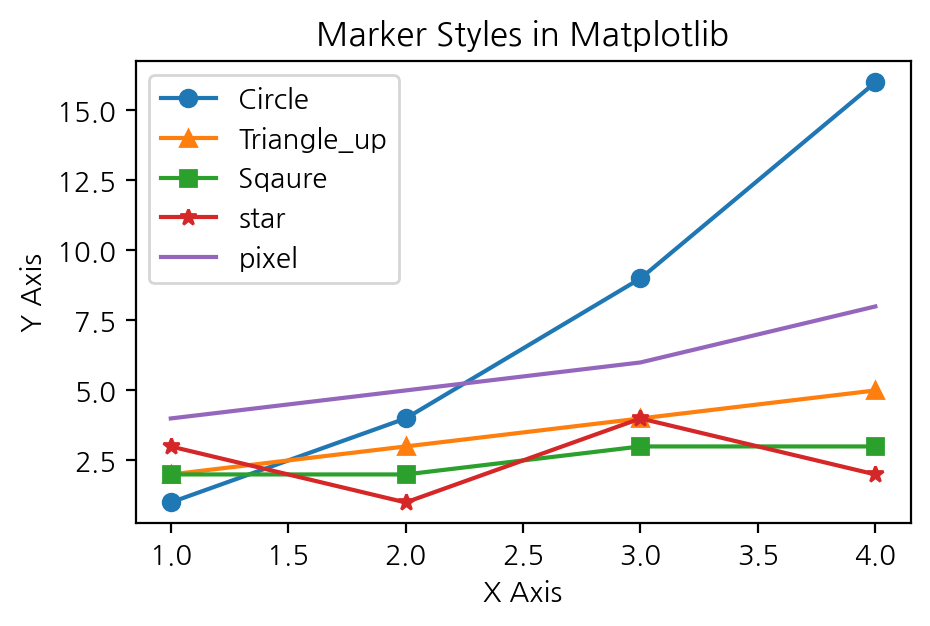

In [ ]:
import matplotlib.pyplot as plt

# 데이터 준비
x = [1, 2, 3, 4]
y1 = [1, 4, 9, 16]
y2 = [2, 3, 4, 5]
y3 = [2, 2, 3, 3]
y4 = [3, 1, 4, 2]
y5 = [4, 5, 6, 8]

# 선 스타일별로 그래프 그리기
plt.plot(x, y1, marker='o', label='Circle')        # 실선
plt.plot(x, y2, marker='^', label='Triangle_up')       # 점선
plt.plot(x, y3, marker='s', label='Sqaure')       # 도트 선
plt.plot(x, y4, marker='*', label='star')    # 대시 도트 선
plt.plot(x, y5, marker=',', label='pixel')    # 픽셀

# 그래프 제목과 축 레이블
plt.title("Marker Styles in Matplotlib")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")

# 범례 추가
plt.legend()

# 그래프 보여주기
plt

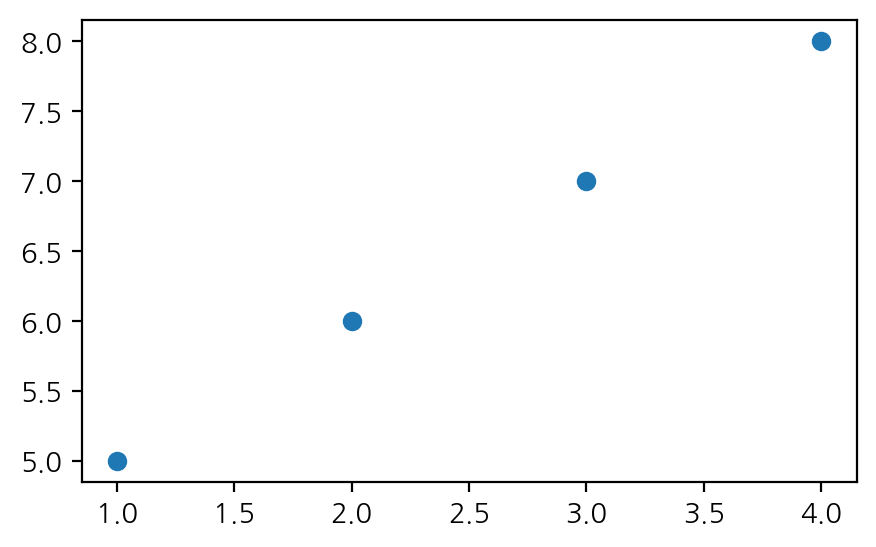

In [ ]:
plt.plot(range(1, 5), range(5, 9), ls='', marker='o')
plt.show()

In [ ]:
vc = tg[tg.supp == "VC"][['len', 'dose']]
oj = tg[tg.supp == "OJ"][['len', 'dose']]

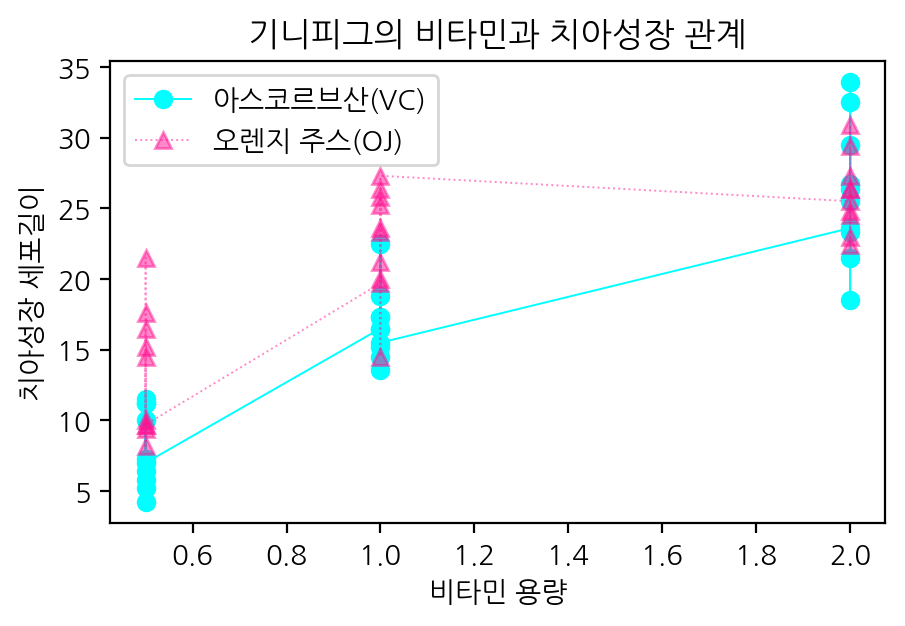

In [ ]:
plt.plot(vc.dose, vc.len, color='cyan', marker='o', label='아스코르브산(VC)', lw=.7)
plt.plot(oj.dose, oj.len, color='deeppink', marker='^', ls=':', label='오렌지 주스(OJ)', lw=.7, alpha=.5)

plt.title("기니피그의 비타민과 치아성장 관계")
plt.xlabel("비타민 용량")
plt.ylabel("치아성장 세포길이")

plt.legend()

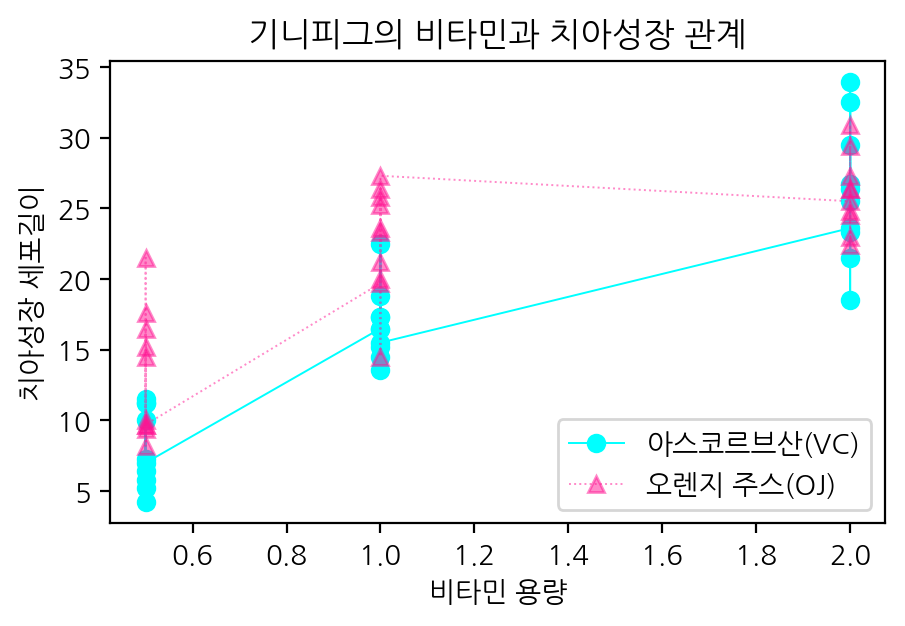

In [ ]:
plt.plot(vc.dose, vc.len, color='cyan', marker='o', label='아스코르브산(VC)', lw=.7)
plt.plot(oj.dose, oj.len, color='deeppink', marker='^', ls=':', label='오렌지 주스(OJ)', lw=.7, alpha=.5)

plt.title("기니피그의 비타민과 치아성장 관계")
plt.xlabel("비타민 용량")
plt.ylabel("치아성장 세포길이")
plt.legend(loc='lower right')

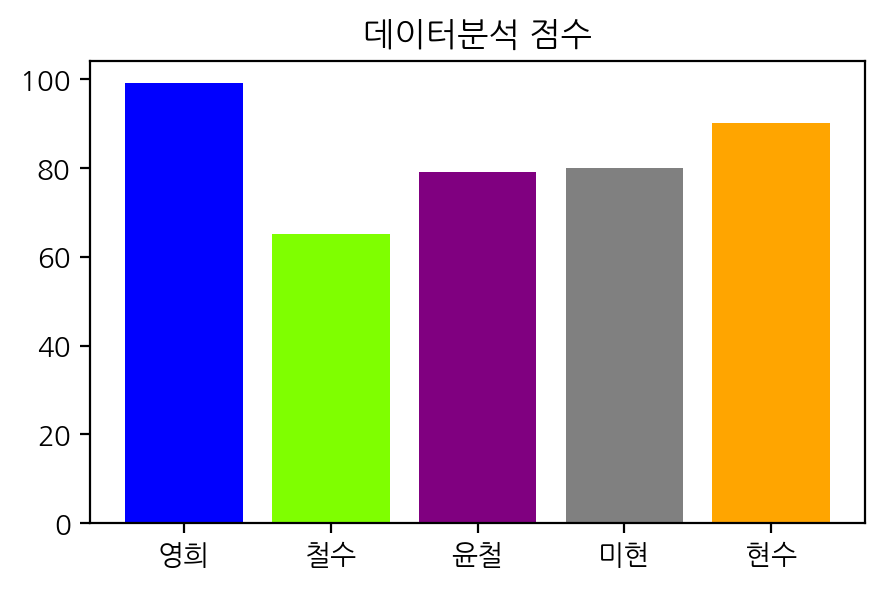

In [ ]:
import matplotlib.pyplot as plt
point = [99, 65, 79, 80, 90]
name = ["영희", "철수", "윤철", "미현", "현수"]
plt.bar(name, point, color = ["blue", "chartreuse", "purple", "grey", "orange"])
plt.title('데이터분석 점수');

Text(0, 0.5, '점수')

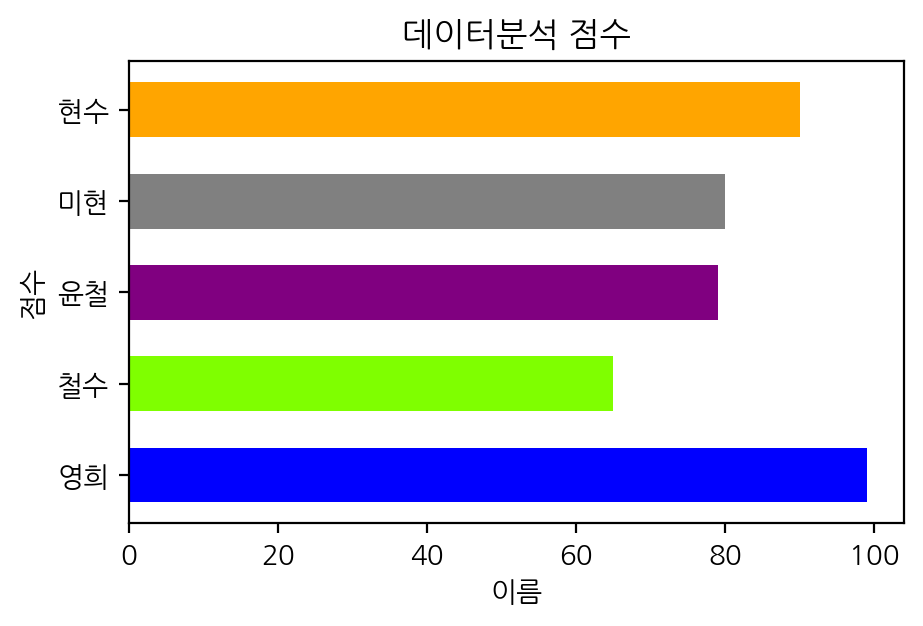

In [ ]:
import matplotlib.pyplot as plt
point = [99, 65, 79, 80, 90]
name = ["영희", "철수", "윤철", "미현", "현수"]
plt.barh(name, point, height = .6, color = ["blue", "chartreuse", "purple", "grey", "orange"])
plt.title('데이터분석 점수')
plt.xlabel('이름')
plt.ylabel('점수')

In [ ]:
from pydataset import data
lcs = data('LifeCycleSavings')
lcs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Australia to Malaysia
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sr      50 non-null     float64
 1   pop15   50 non-null     float64
 2   pop75   50 non-null     float64
 3   dpi     50 non-null     float64
 4   ddpi    50 non-null     float64
dtypes: float64(5)
memory usage: 2.3+ KB


In [ ]:
lcs.describe()

,sr,pop15,pop75,dpi,ddpi
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,9.671000,35.089600,2.293000,1106.758400,3.757600
std,4.480407,9.151727,1.290771,990.868889,2.869871
min,0.600000,21.440000,0.560000,88.940000,0.220000
25%,6.970000,26.215000,1.125000,288.207500,2.002500
50%,10.510000,32.575000,2.175000,695.665000,3.000000
75%,12.617500,44.065000,3.325000,1795.622500,4.477500
max,21.100000,47.640000,4.700000,4001.890000,16.710000


In [ ]:
df= lcs[:5][['pop15']]
df

,pop15
Australia,29.35
Austria,23.32
Belgium,23.80
Bolivia,41.89
Brazil,42.19


Text(0, 0.5, '15세미만 인구비율(%)')

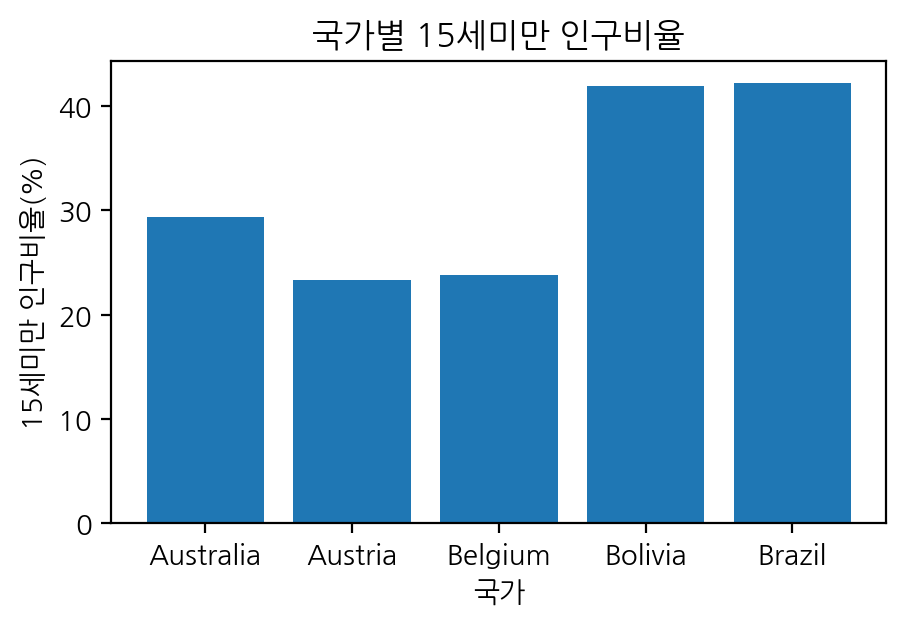

In [ ]:
plt.bar(df.index, df.pop15)
plt.title("국가별 15세미만 인구비율")
plt.xlabel("국가")
plt.ylabel("15세미만 인구비율(%)")

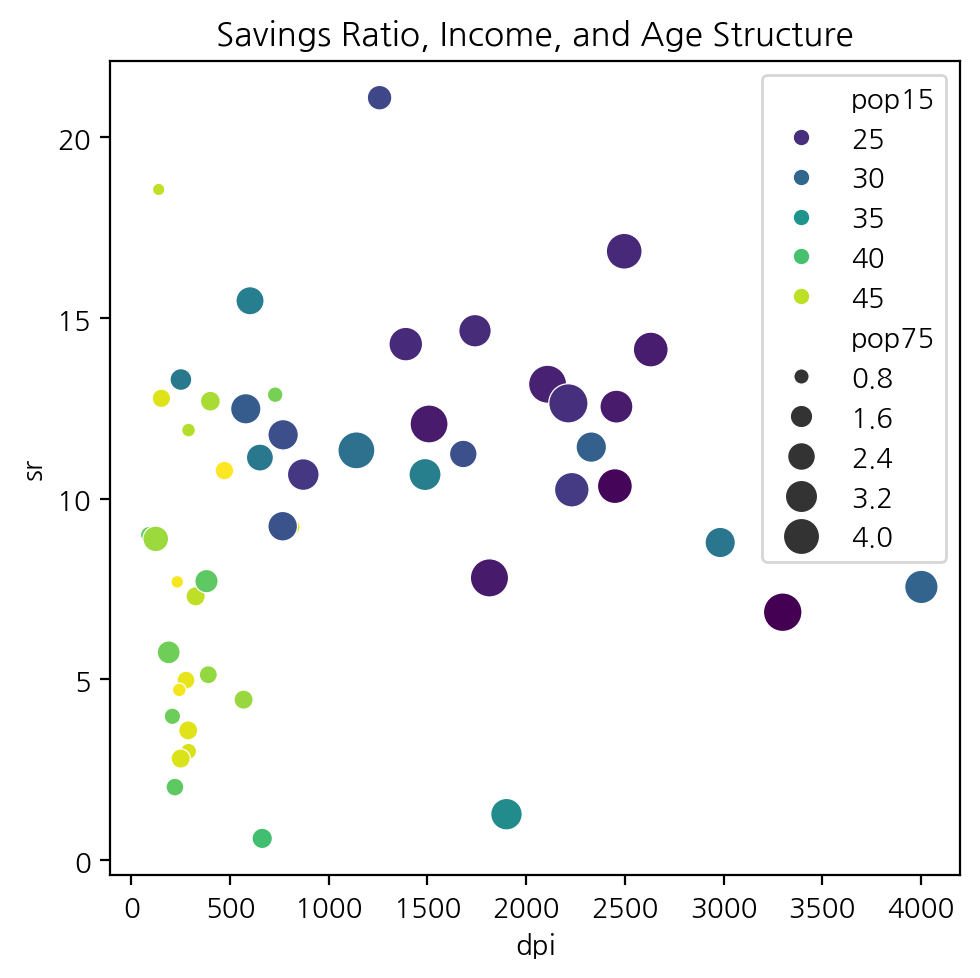

In [ ]:
plt.figure(figsize=(5, 5))
sns.scatterplot(data=lcs, x='dpi', y='sr', hue='pop15',
palette='viridis', size='pop75', sizes=(20, 200))
plt.title('Savings Ratio, Income, and Age Structure')
plt.xlabel('dpi')
plt.ylabel('sr')
plt.tight_layout()
plt.show()

In [ ]:
from pydataset import data
mtc = data('mtcars')
mtc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, Mazda RX4 to Volvo 142E
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     32 non-null     float64
 1   cyl     32 non-null     int64  
 2   disp    32 non-null     float64
 3   hp      32 non-null     int64  
 4   drat    32 non-null     float64
 5   wt      32 non-null     float64
 6   qsec    32 non-null     float64
 7   vs      32 non-null     int64  
 8   am      32 non-null     int64  
 9   gear    32 non-null     int64  
 10  carb    32 non-null     int64  
dtypes: float64(5), int64(6)
memory usage: 3.0+ KB


In [ ]:
mtc_cyl = mtc.cyl.value_counts()
mtc_cyl

,count
cyl,
8,14
4,11
6,7


Text(0, 0.5, '자동차 수')

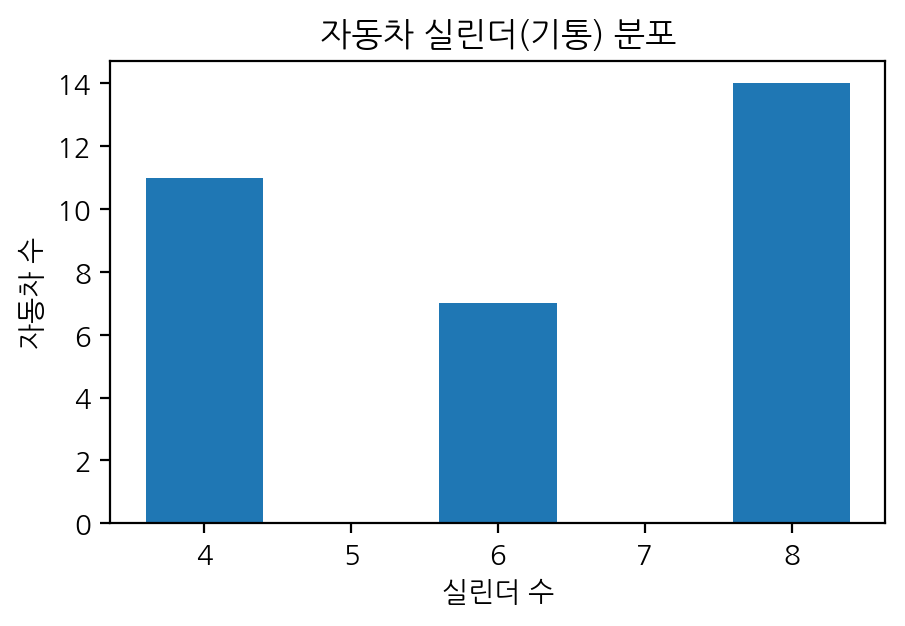

In [ ]:
plt.bar(mtc_cyl.index, mtc_cyl)
plt.title("자동차 실린더(기통) 분포")
plt.xlabel("실린더 수")
plt.ylabel("자동차 수")

(array([0, 1, 2]), [Text(0, 0, '8'), Text(1, 0, '4'), Text(2, 0, '6')])

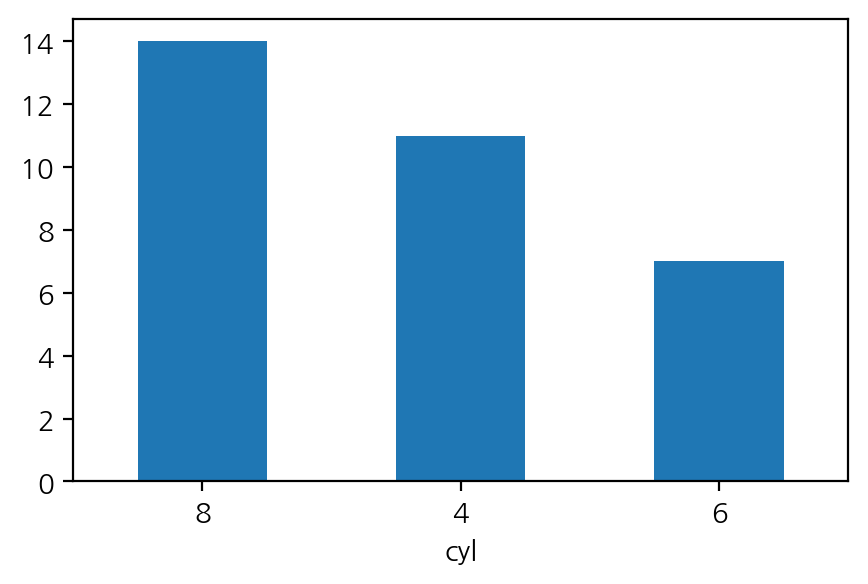

In [ ]:
mtc.cyl.value_counts().plot.bar()
plt.xticks(rotation=360)

<Axes: xlabel='gear', ylabel='count'>

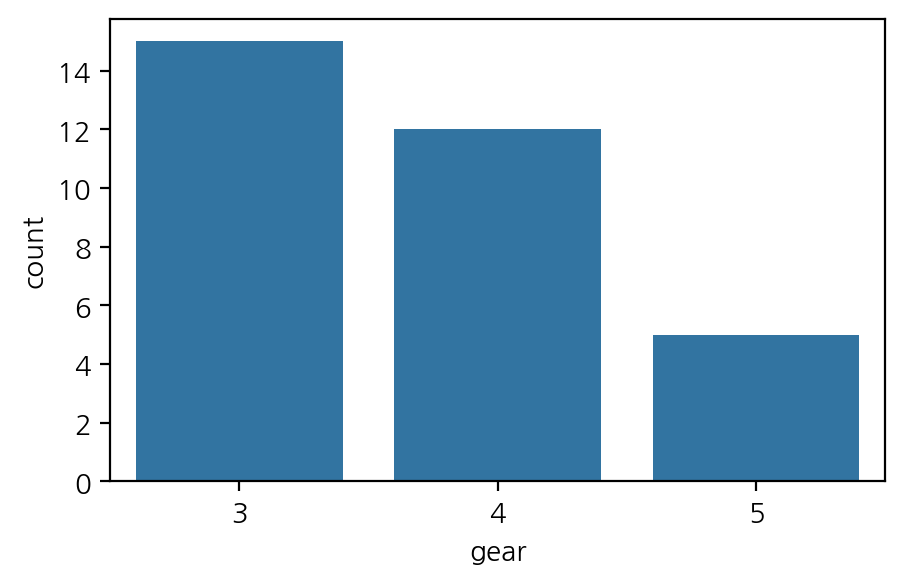

In [ ]:
import seaborn as sns
sns.countplot(mtc, x = 'gear')

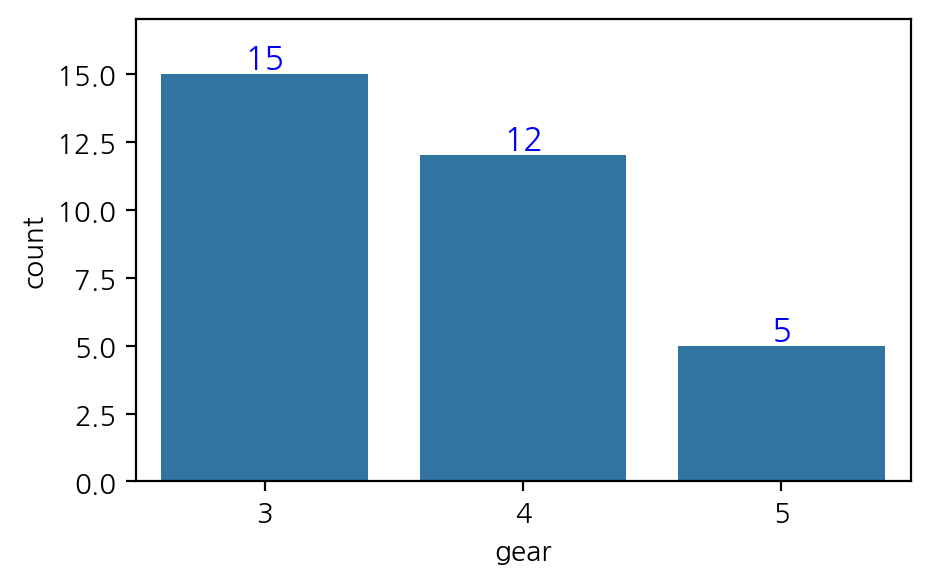

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(
    data=mtc, x='gear', order=mtc.gear.value_counts().index)

for p in ax.patches:
    height = p.get_height()  # 빈도 수
    ax.text( x=(p.get_x() + p.get_width() / 2.),y=(height + 0.2),
     s=int(height), ha='center', size=12,color='blue')
ax.set_ylim(0, 17)  # y축 범위를 0부터 17까지 설정
plt.show()

##9.2 상자그림과 히스토그램


In [ ]:
from pydataset import data
mtc = data('mtcars')
mtc.mpg.quantile([0., .25, .50, .75, 1])

,mpg
0.00,10.400
0.25,15.425
0.50,19.200
0.75,22.800
1.00,33.900


In [ ]:
mtc.mpg.describe()[3:]

,mpg
min,10.400
25%,15.425
50%,19.200
75%,22.800
max,33.900


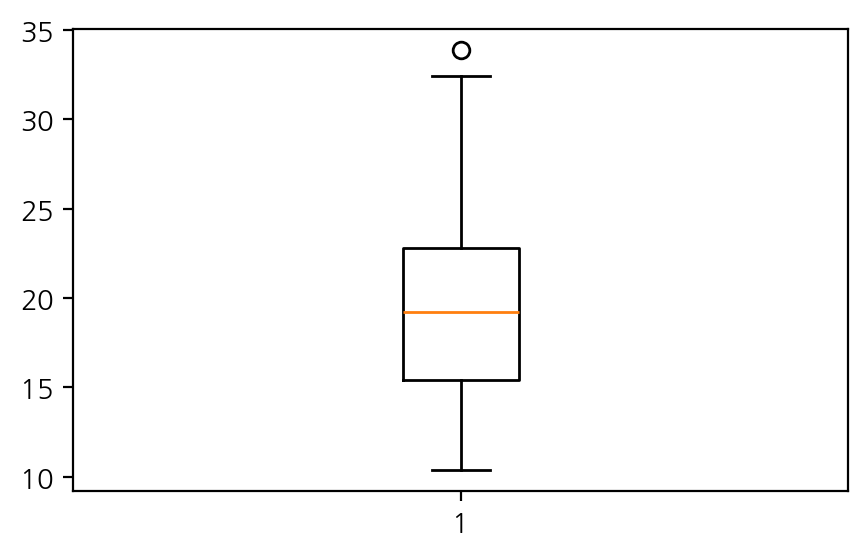

In [ ]:
import matplotlib.pyplot as plt
plt.boxplot(mtc.mpg)
plt.show()

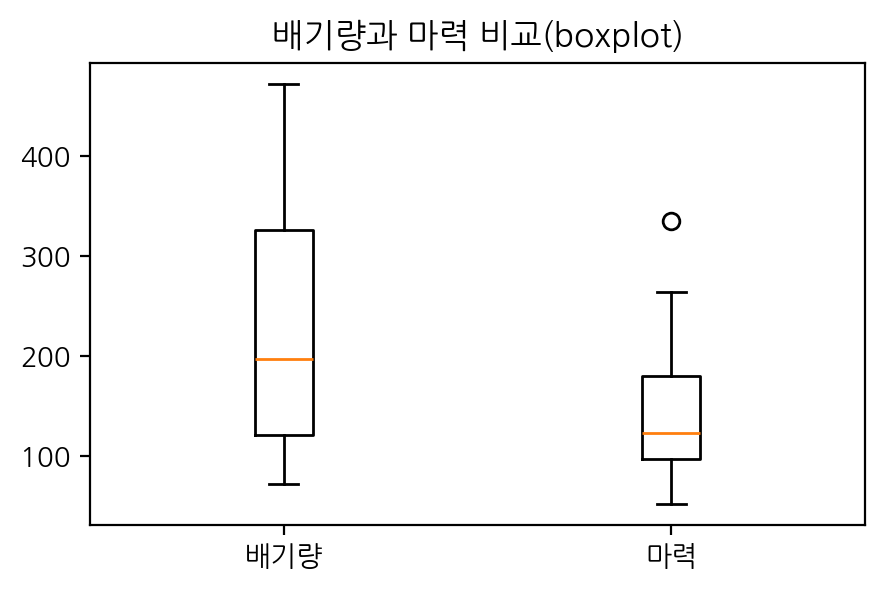

In [ ]:
import numpy as np
plt.boxplot([mtc.disp, mtc.hp])
plt.title("배기량과 마력 비교(boxplot)")
plt.xticks(ticks = np.arange(1, 3), labels = ["배기량", "마력"])
plt.show()

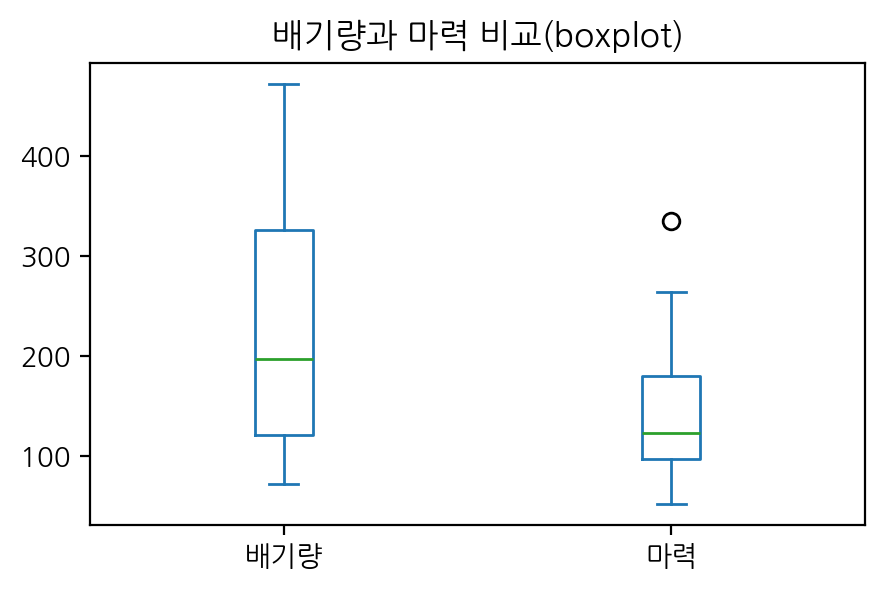

In [ ]:
mtc[['disp', 'hp']].plot(title="배기량과 마력 비교(boxplot)", kind='box')
plt.xticks(ticks = np.arange(1, 3), labels = ["배기량", "마력"])
plt.show()

(array([2., 4., 6., 6., 5., 3., 1., 1., 2., 2.]),
 array([10.4 , 12.75, 15.1 , 17.45, 19.8 , 22.15, 24.5 , 26.85, 29.2 ,
        31.55, 33.9 ]),
 <BarContainer object of 10 artists>)

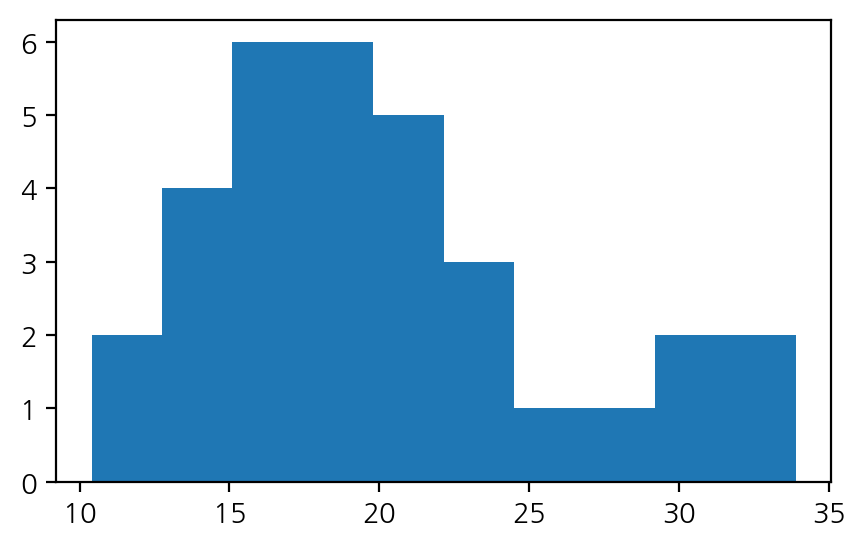

In [ ]:
plt.hist(mtc.mpg)


(array([2., 4., 6., 6., 5., 3., 1., 1., 2., 2.]),
 array([10.4 , 12.75, 15.1 , 17.45, 19.8 , 22.15, 24.5 , 26.85, 29.2 ,
        31.55, 33.9 ]),
 <BarContainer object of 10 artists>)

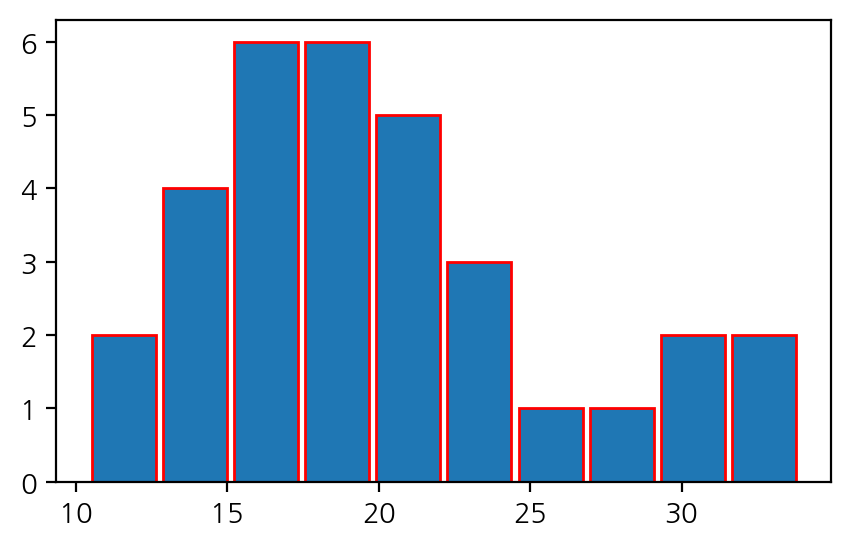

In [ ]:
plt.hist(mtc.mpg, edgecolor='red', rwidth=.9)

(array([3., 3., 3., 3., 9., 7., 1., 0., 0., 3.]),
 array([1.513 , 1.9041, 2.2952, 2.6863, 3.0774, 3.4685, 3.8596, 4.2507,
        4.6418, 5.0329, 5.424 ]),
 <BarContainer object of 10 artists>)

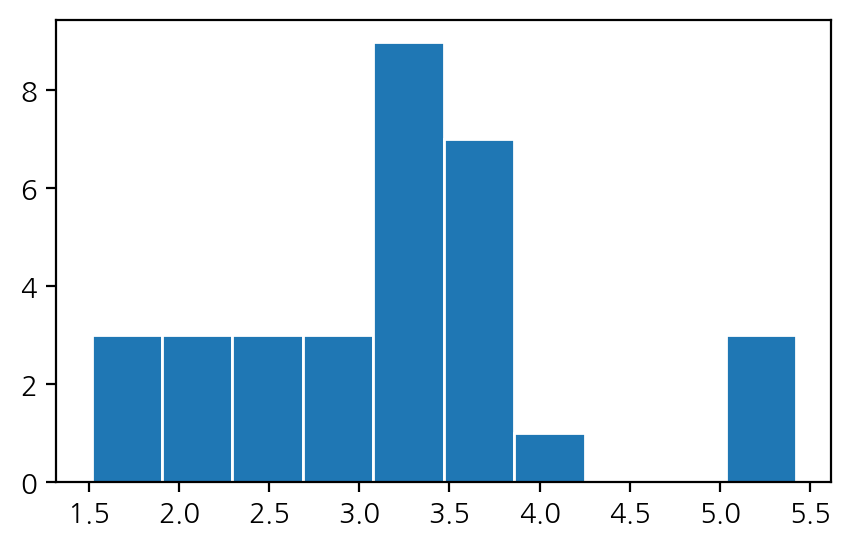

In [ ]:
plt.hist(mtc.wt, edgecolor='white')

(array([ 6.,  6., 16.,  1.,  3.]),
 array([1.513 , 2.2952, 3.0774, 3.8596, 4.6418, 5.424 ]),
 <BarContainer object of 5 artists>)

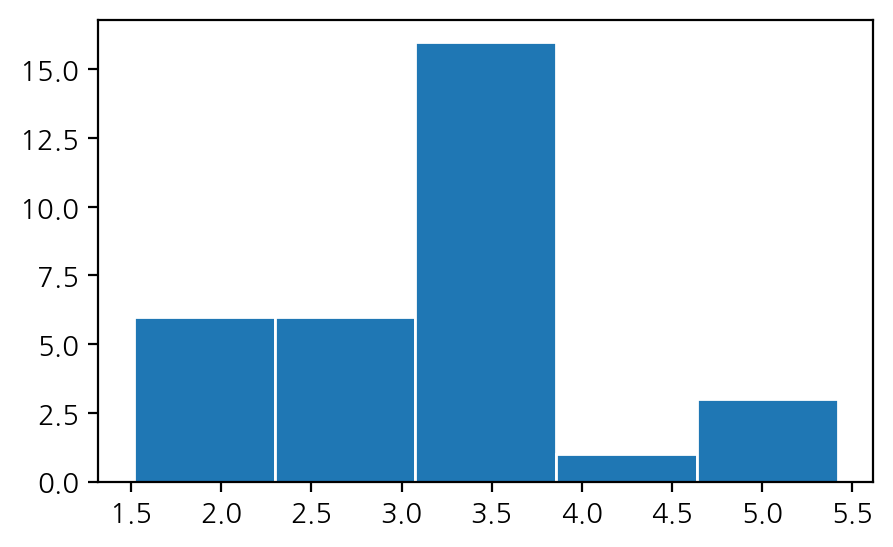

In [ ]:
plt.hist(mtc.wt, bins = 5, edgecolor='white')

(array([4., 4., 4., 9., 7., 1., 0., 3.]),
 array([1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5]),
 <BarContainer object of 8 artists>)

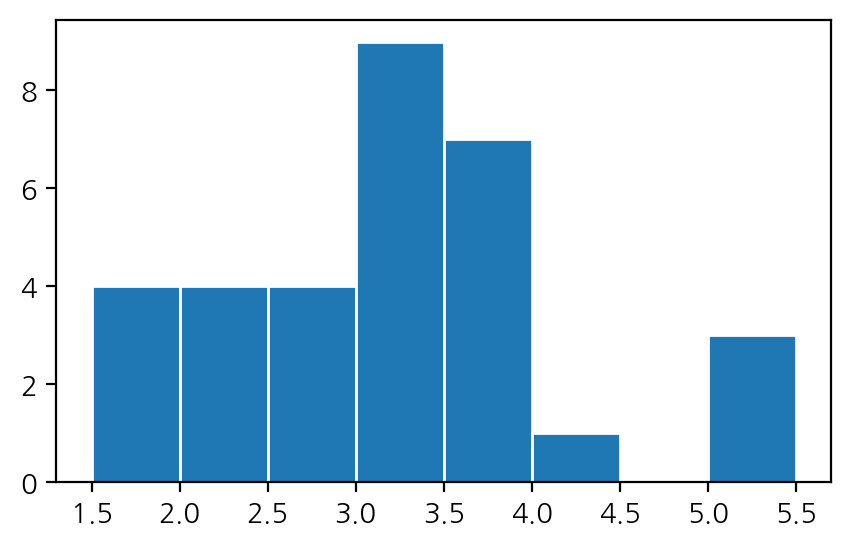

In [ ]:
plt.hist(mtc.wt, bins = np.arange(1.5, 5.6, 0.5), edgecolor='white')

(array([ 8., 21.,  3.]),
 array([1.5, 2.5, 4.5, 5.5]),
 <BarContainer object of 3 artists>)

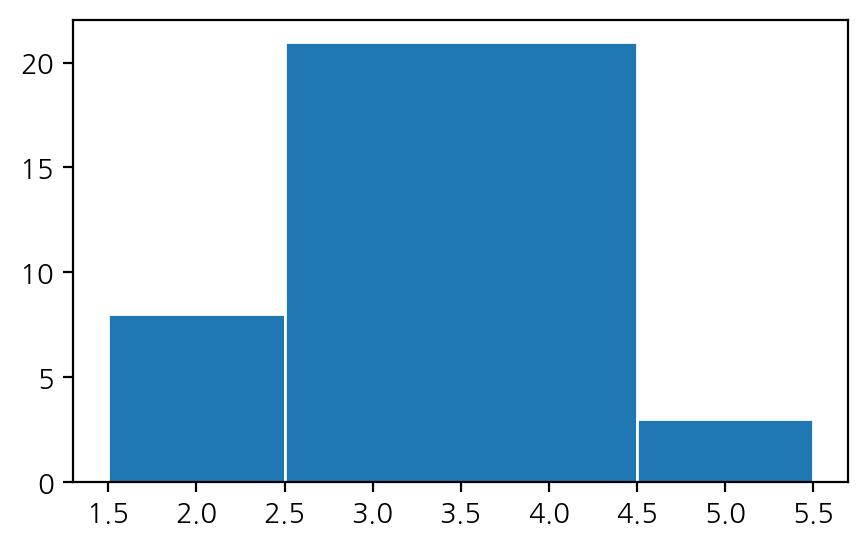

In [ ]:
plt.hist(mtc.wt, bins = [1.5, 2.5, 4.5, 5.5], edgecolor='white')

(array([0.25    , 0.328125, 0.09375 ]),
 array([1.5, 2.5, 4.5, 5.5]),
 <BarContainer object of 3 artists>)

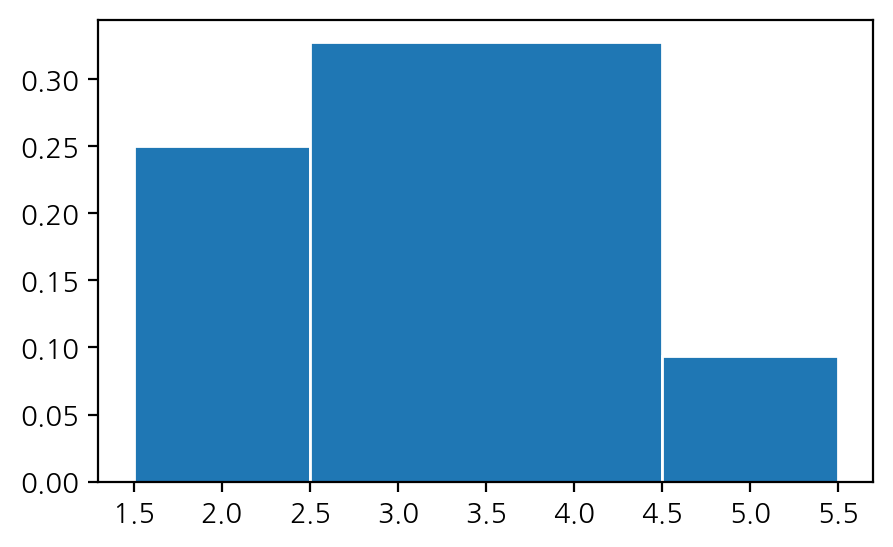

In [ ]:
plt.hist(mtc.wt, bins = [1.5, 2.5, 4.5, 5.5], density=True, edgecolor='white')

In [ ]:
from pydataset import data
iris = data('iris')
iris.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


In [ ]:
iris.Species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [ ]:
iris.Species.value_counts()

,count
Species,
setosa,50
versicolor,50
virginica,50


[ 4.  5.  7. 16.  9.  5. 13. 14. 10.  6. 10. 16.  7. 11.  4.  2.  4.  1.
  5.  1.]
[4.3  4.48 4.66 4.84 5.02 5.2  5.38 5.56 5.74 5.92 6.1  6.28 6.46 6.64
 6.82 7.   7.18 7.36 7.54 7.72 7.9 ]
<BarContainer object of 20 artists>


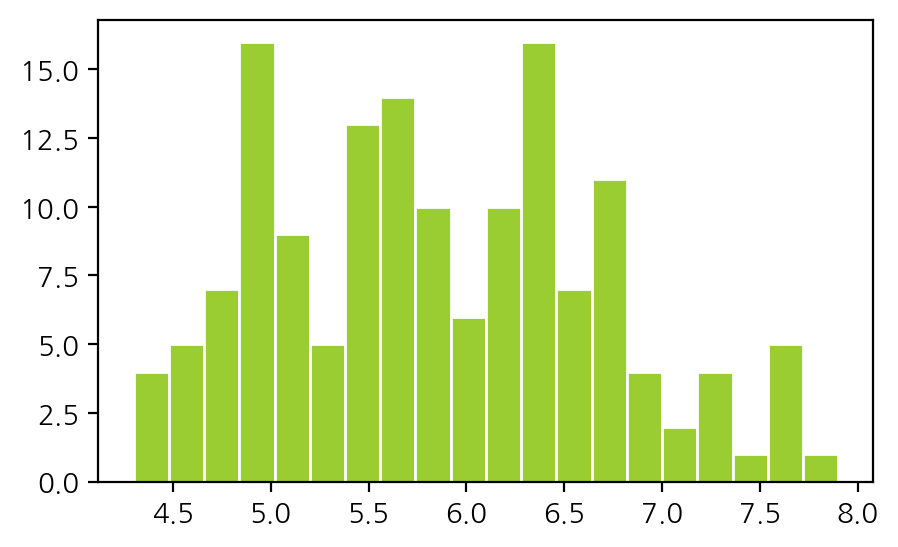

In [ ]:
n, bins, patches = plt.hist(iris['Sepal.Length'], bins = 20,
                            color='yellowgreen', edgecolor='white')
print(n)
print(bins)
print(patches)

In [ ]:
n

array([ 4.,  5.,  7., 16.,  9.,  5., 13., 14., 10.,  6., 10., 16.,  7.,
       11.,  4.,  2.,  4.,  1.,  5.,  1.])

In [ ]:
bins

array([4.3 , 4.48, 4.66, 4.84, 5.02, 5.2 , 5.38, 5.56, 5.74, 5.92, 6.1 ,
       6.28, 6.46, 6.64, 6.82, 7.  , 7.18, 7.36, 7.54, 7.72, 7.9 ])

In [ ]:
patches

<BarContainer object of 20 artists>

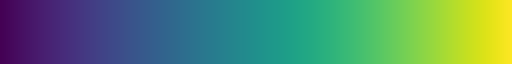

In [ ]:
plt.cm.viridis

In [ ]:
n[0]

np.float64(4.0)

In [ ]:
max(n)

np.float64(16.0)

In [ ]:
n[1]/max(n)

np.float64(0.3125)

In [ ]:
plt.cm.viridis(n[1]/max(n))

(np.float64(0.19943),
 np.float64(0.387607),
 np.float64(0.554642),
 np.float64(1.0))

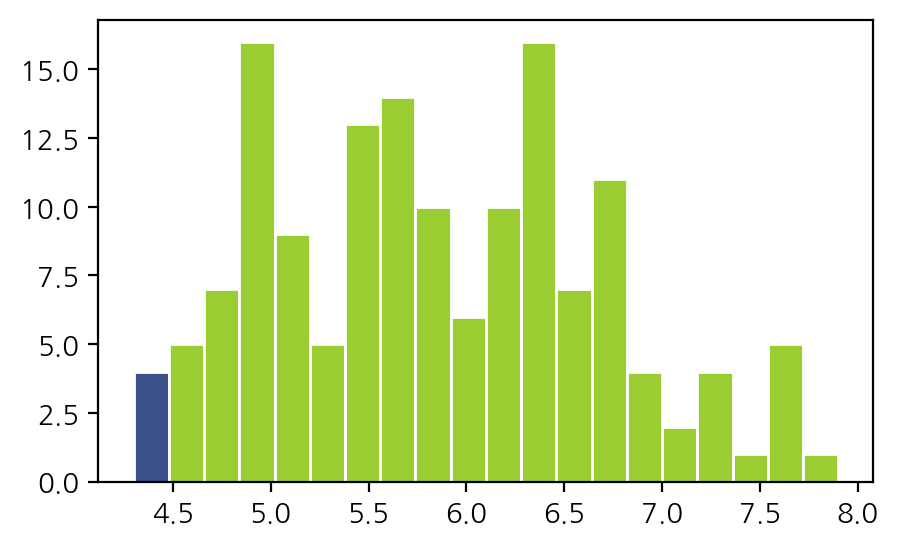

In [ ]:
n, bins, patches = plt.hist(iris['Sepal.Length'],bins = 20, color='yellowgreen',edgecolor='white')

for i in range(len(patches)):
  patches[i].set_facecolor(plt.cm.viridis(n[i]/max(n)))
  plt.show()

<Axes: ylabel='Density'>

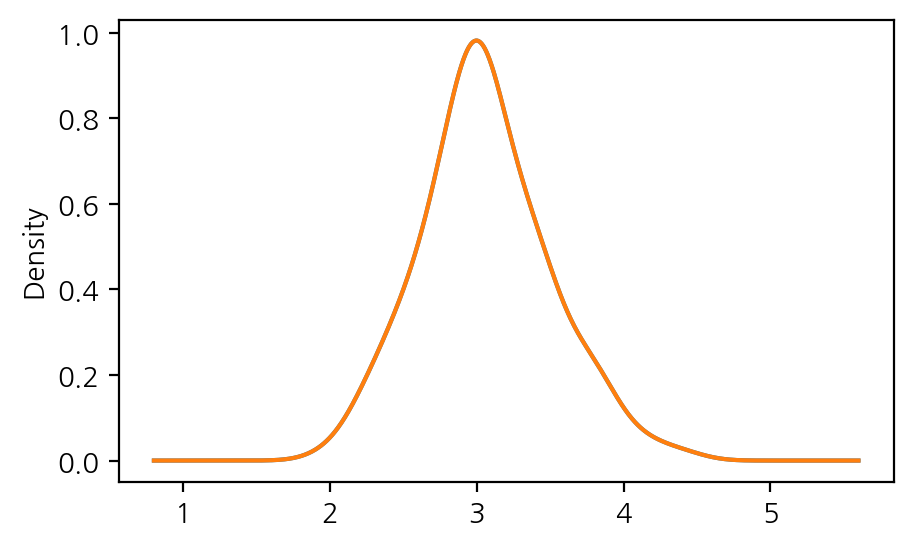

In [ ]:
iris['Sepal.Width'].plot.density()
iris['Sepal.Width'].plot.kde()


##9.3 바이올린과 상관관계 시각화

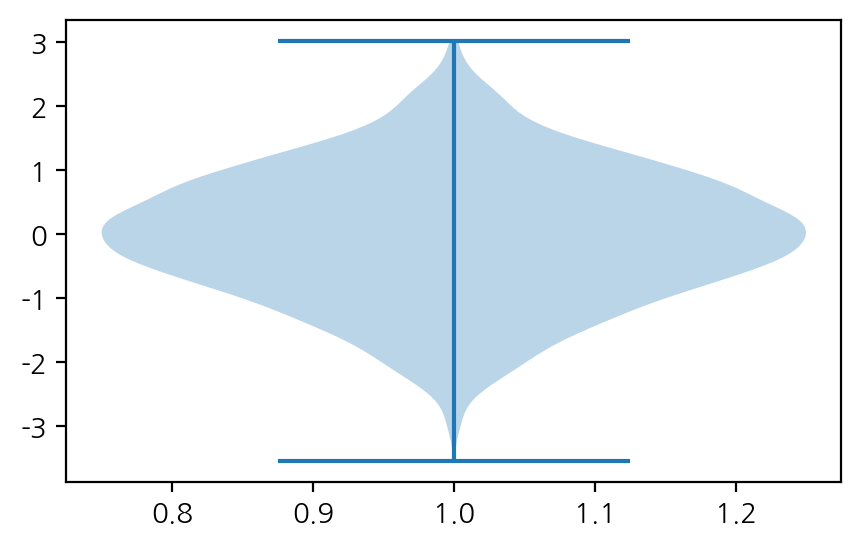

In [ ]:
data = np.random.randn(2000)
plt.violinplot(data);

{'bodies': [<matplotlib.collections.FillBetweenPolyCollection at 0x7f85e8c96f60>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x7f85e81ba540>,
 'cmins': <matplotlib.collections.LineCollection at 0x7f85eaba71a0>,
 'cbars': <matplotlib.collections.LineCollection at 0x7f85eaba6930>,
 'cquantiles': <matplotlib.collections.LineCollection at 0x7f85eab9d730>}

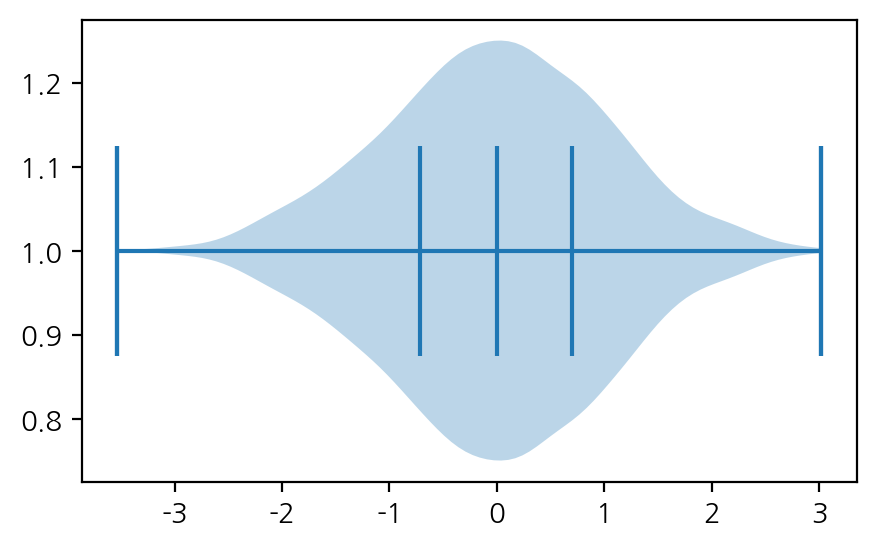

In [ ]:
plt.violinplot(data, quantiles=[0, .25, .5, .75, 1], vert=False)

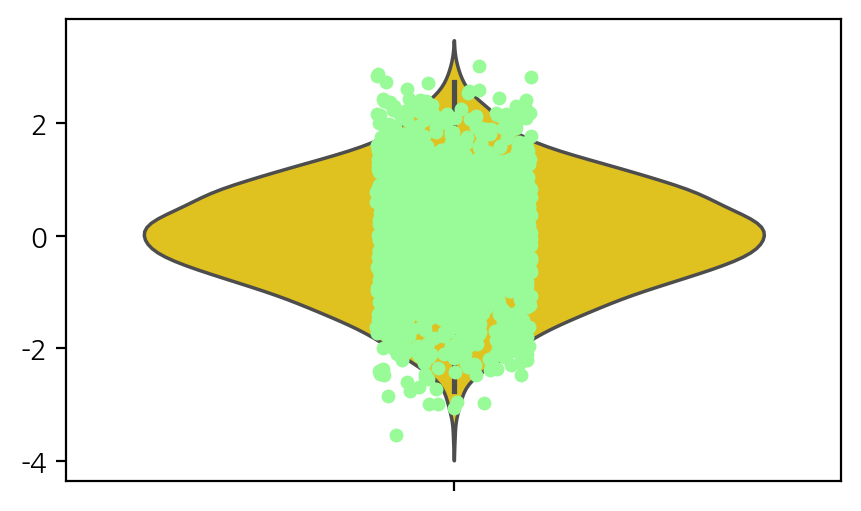

In [ ]:
import seaborn as sns
sns.violinplot(data, color='gold');
sns.stripplot(data, color='palegreen');

<Axes: xlabel='Species', ylabel='Sepal.Length'>

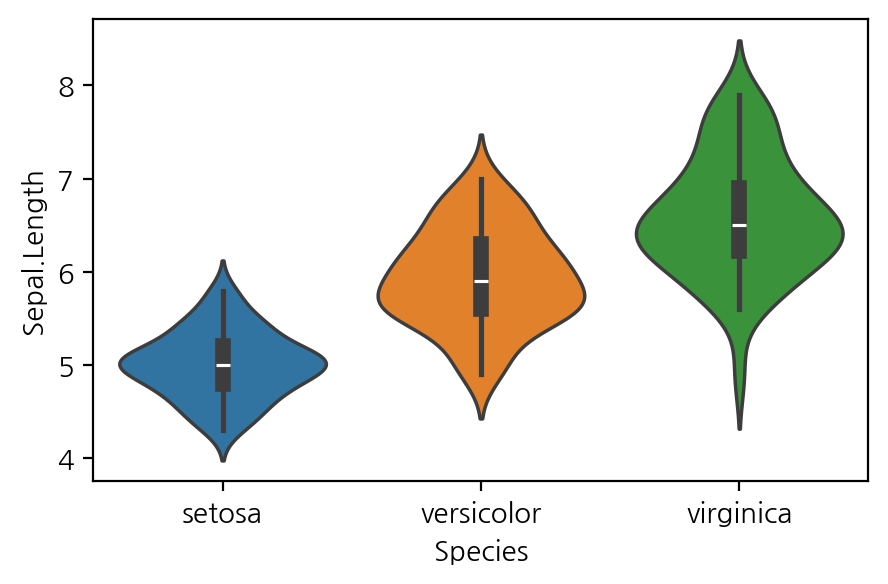

In [ ]:
from pydataset import data
iris = data('iris')
import seaborn as sns
sns.violinplot(data=iris, x='Species', y='Sepal.Length', hue='Species')